In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("mall customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df=df.drop('CustomerID',axis=1)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [5]:
df=df.rename(columns={'Annual Income (k$)':'income','Spending Score (1-100)':'score'})
df.head()

,Gender,Age,income,score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [6]:
df1=df.copy()
df2=df.copy()


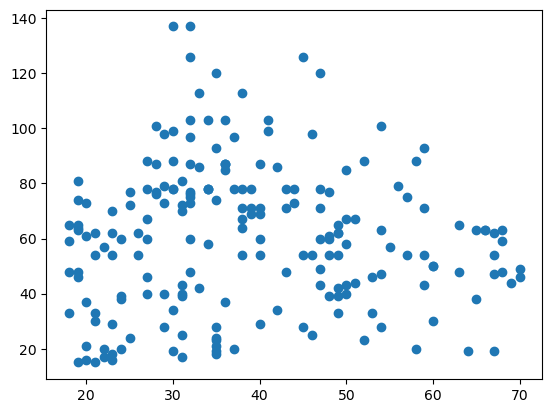

In [7]:
plt.scatter(df['Age'],df['income'])

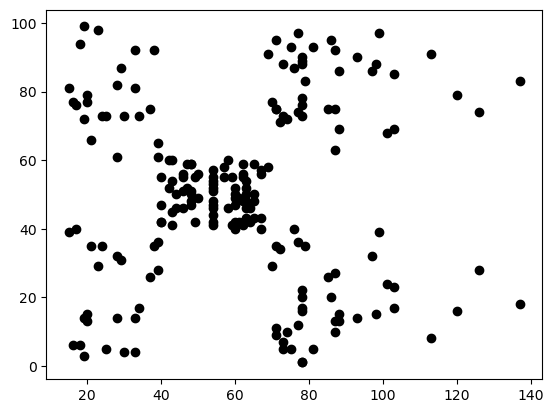

In [8]:
plt.scatter(df.income,df.score,color='black')

In [9]:
import seaborn as sns

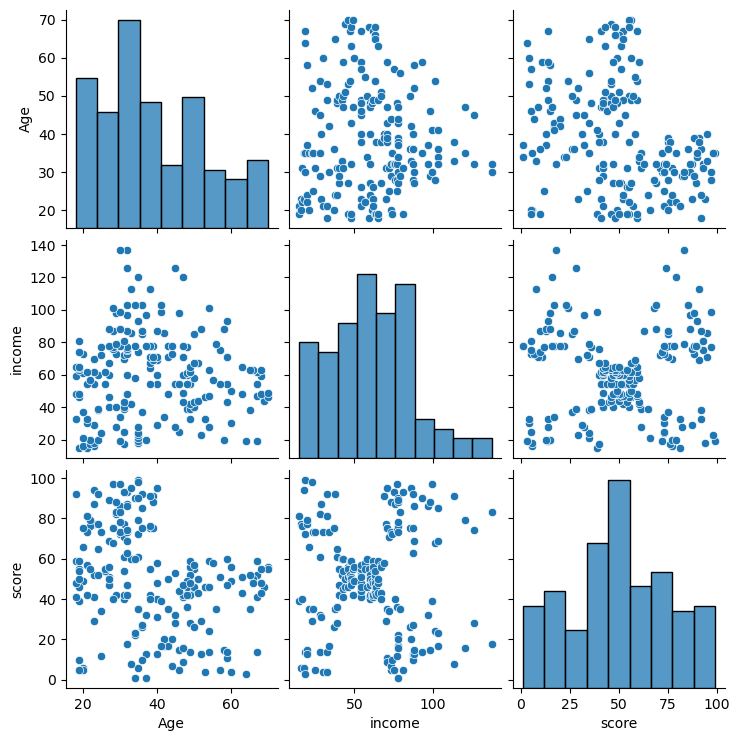

In [17]:
sns.pairplot(df[['Age','income','score']])

In [27]:
from sklearn.cluster import KMeans

In [28]:
km=KMeans()

In [31]:
df['Age'].dtypes

dtype('int64')

In [33]:
km.fit(df[['Age','income']])

KMeans()

In [35]:
df['new_cluster']=km.predict(df[['Age','income']])

In [37]:
df.tail()

,Gender,Age,income,score,new_cluster
195,Female,35,120,79,3
196,Female,45,126,28,3
197,Male,32,126,74,3
198,Male,32,137,18,3
199,Male,30,137,83,3


In [39]:
df0=df[df['new_cluster']==0]
df0

,Gender,Age,income,score,new_cluster
8,Male,64,19,3,0
10,Male,67,19,14,0
12,Female,58,20,15,0
18,Male,52,23,29,0
22,Female,46,25,5,0
24,Female,54,28,14,0
26,Female,45,28,32,0
28,Female,40,29,31,0
30,Male,60,30,4,0
32,Male,53,33,4,0


In [41]:
df0=df[df['new_cluster']==0]
df1=df[df['new_cluster']==1]
df3=df[df['new_cluster']==3]
df4=df[df['new_cluster']==4]
df5=df[df['new_cluster']==5]
df6=df[df['new_cluster']==6]
df7=df[df['new_cluster']==7]

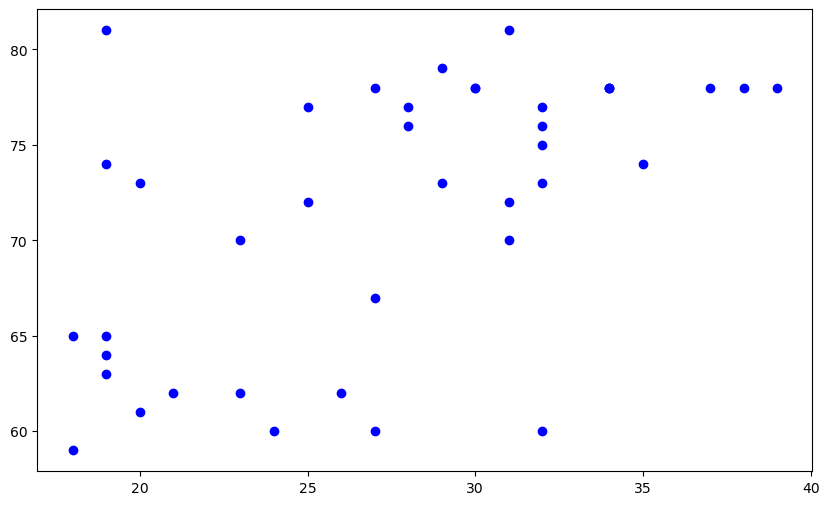

In [43]:
plt.figure(figsize=(10,6))
#plt.scatter(df0.Age,df0.income,color='black')
plt.scatter(df1.Age,df1.income,color='blue')


CENTER OF CLUSTER

In [46]:
center=km.cluster_centers_

In [48]:
center

array([[ 51.8       ,  35.28      ],
       [ 27.425     ,  71.55      ],
       [ 25.54545455,  43.18181818],
       [ 36.5       , 124.        ],
       [ 64.63157895,  54.68421053],
       [ 38.21428571,  93.        ],
       [ 45.57142857,  65.71428571],
       [ 27.43478261,  21.        ]])

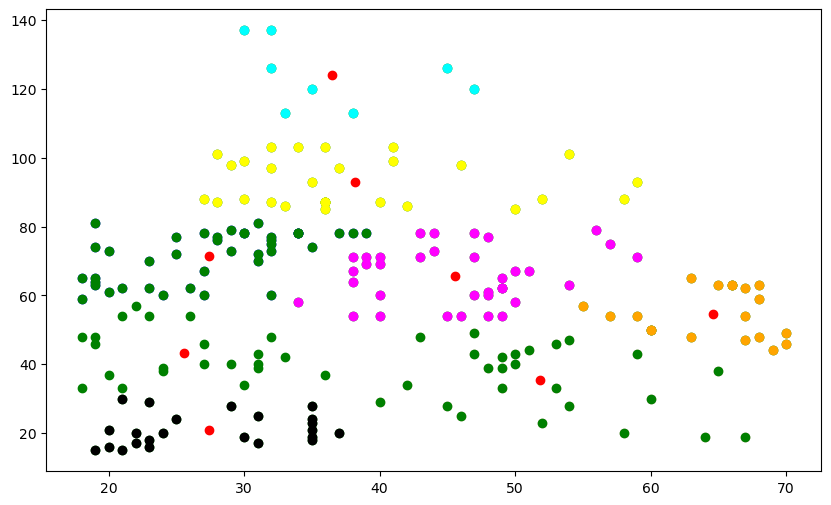

In [50]:
plt.figure(figsize=(10,6))
plt.scatter(df0.Age,df0.income,color='pink')
plt.scatter(df1.Age,df1.income,color='blue')
plt.scatter(df2.Age,df2.income,color='green')
plt.scatter(df3.Age,df3.income,color='cyan')
plt.scatter(df4.Age,df4.income,color='orange')
plt.scatter(df5.Age,df5.income,color='yellow')
plt.scatter(df6.Age,df6.income,color='magenta')
plt.scatter(df7.Age,df7.income,color='black')
plt.scatter(center[:,0],center[:,1],color='red')
plt.show()

In [52]:
df0.shape

(25, 5)

In [54]:
df1.shape

(40, 5)

In [56]:
wcss=[]
clustes_range=range(1,15)
for k in clustes_range:
    km2=KMeans(n_clusters=k)
    km2.fit(df[['Age','income']])
    wcss.append(km2.inertia_)

In [58]:
wcss

[176108.78000000003,
 87189.0462597429,
 59525.857573798756,
 39847.42175010225,
 32783.03836996337,
 26294.33932022084,
 23586.2815718764,
 19543.370436587713,
 16997.851020206916,
 16665.038553495073,
 12262.182708505356,
 11880.509963355358,
 10257.759860108932,
 10340.787705350205]

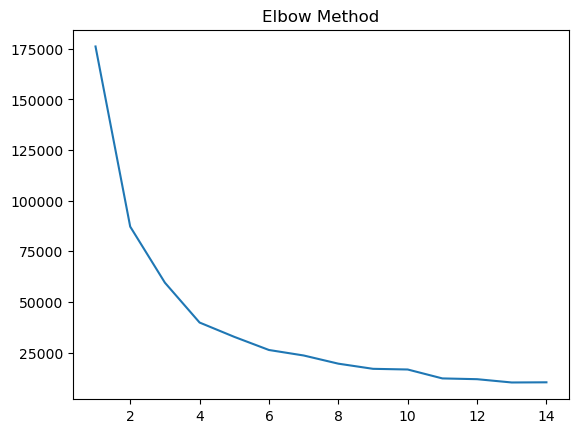

In [60]:
plt.plot(clustes_range,wcss)
plt.title('Elbow Method')
plt.show()

In [62]:
km2=KMeans(n_clusters=4,random_state=42)

In [64]:
km2.fit(df[['Age','income']])

KMeans(n_clusters=4, random_state=42)

In [66]:
df['new_cluster2']=km2.predict(df[['Age','income']])
df.head()

,Gender,Age,income,score,new_cluster,new_cluster2
0,Male,19,15,39,7,2
1,Male,21,15,81,7,2
2,Female,20,16,6,7,2
3,Female,23,16,77,7,2
4,Female,31,17,40,7,2


In [68]:
center2=km2.cluster_centers_
center2

array([[ 55.66071429,  51.01785714],
       [ 31.95890411,  72.95890411],
       [ 29.44680851,  29.21276596],
       [ 39.        , 106.5       ]])

In [109]:
df00=df[df['new_cluster2']==0]
df11=df[df['new_cluster2']==1]
df22=df[df['new_cluster2']==2]
df33=df[df['new_cluster2']==3]

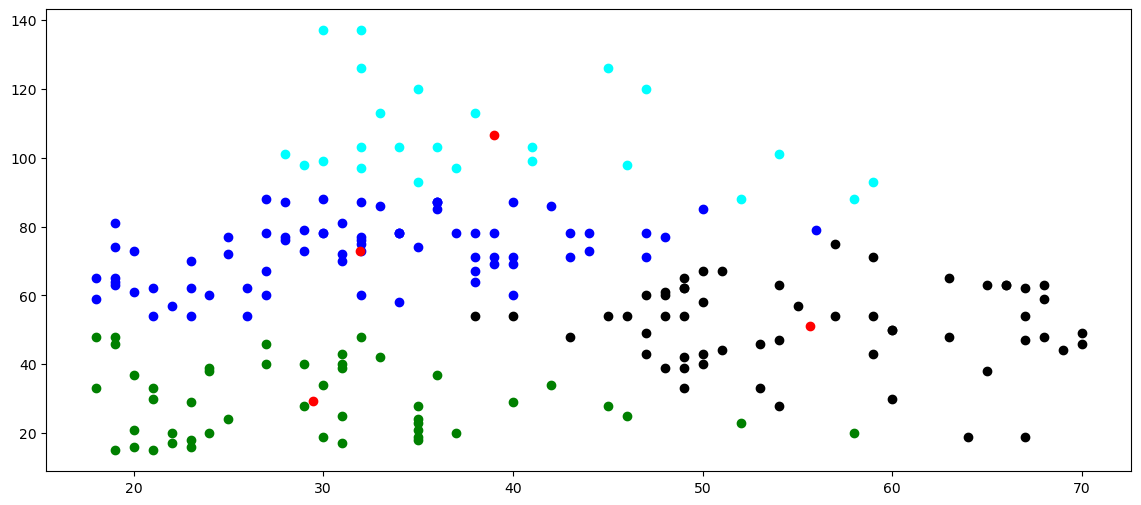

In [115]:
plt.figure(figsize=(14,6))
plt.scatter(df00.Age,df00.income,color='black')
plt.scatter(df11.Age,df11.income,color='blue')
plt.scatter(df22.Age,df22.income,color='green')
plt.scatter(df33.Age,df33.income,color='cyan')
plt.scatter(center2[:,0],center2[:,1],color='red')

In [97]:
df00=df[df['new_cluster2']==3]
df00

,Gender,Age,income,score,new_cluster,new_cluster2
174,Female,52,88,13,5,3
176,Male,58,88,15,5,3
178,Male,59,93,14,5,3
179,Male,35,93,90,5,3
180,Female,37,97,32,5,3
181,Female,32,97,86,5,3
182,Male,46,98,15,5,3
183,Female,29,98,88,5,3
184,Female,41,99,39,5,3
185,Male,30,99,97,5,3


In [101]:
center2=km2.cluster_centers_
center2

array([[ 55.66071429,  51.01785714],
       [ 31.95890411,  72.95890411],
       [ 29.44680851,  29.21276596],
       [ 39.        , 106.5       ]])

In [105]:
km2.labels_

array([2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1,
       3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3], dtype=int32)